# **Code**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -U pandas
!pip install folium
!pip install rasterio
!pip install python-docx

import rasterio
import numpy as np
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout, HTML
from IPython.display import display, clear_output
import pandas as pd
import datetime
import getpass
import folium
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from google.colab import files
import docx
from docx.shared import Pt
import random

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 80.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.0 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.0 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.0 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.5 MB/s eta 0:00:00


In [2]:
BASE_IMG_PATH = '/content/drive/My Drive/Internship_project/Singrauli_Merged_Image.tif'
CNN15_IMG_PATH = '/content/drive/My Drive/Internship_project/Singrauli_LULC_CNN15_2024.tif'
CNN9_IMG_PATH = '/content/drive/My Drive/Internship_project/Singrauli_LULC_CNN9_2024.tif'
RF_IMG_PATH = '/content/drive/My Drive/Internship_project/Singrauli_LULC_RF_2024.tif'


In [3]:
STANDARD_CLASS_LABELS = {
    1: 'Water',
    2: 'Agriculture',
    3: 'Settlement',
    4: 'Mining',
    5: 'Barren',
    6: 'Forest'
}

# CNN format (0-5) - as stored in CNN images
CNN_CLASS_LABELS = {
    0: 'Forest',
    1: 'Water',
    2: 'Agriculture',
    3: 'Settlement',
    4: 'Mining',
    5: 'Barren'
}

# Mapping: CNN class code → Standard class code
CNN_TO_STANDARD = {
    0: 6,  # Forest
    1: 1,  # Water
    2: 2,  # Agriculture
    3: 3,  # Settlement
    4: 4,  # Mining
    5: 5   # Barren
}

# Mapping: Standard class code → CNN class code
STANDARD_TO_CNN = {v: k for k, v in CNN_TO_STANDARD.items()}


def remap_cnn_to_standard(cnn_class):
    """Convert CNN class code (0-5) to Standard class code (1-6)"""
    return CNN_TO_STANDARD.get(cnn_class, cnn_class)


def create_stratified_sampling_plan(image_path, is_cnn_image, points_per_class):
    """
    Generates an ORDERED, stratified sampling plan.
    Returns a list of (y, x, class_name) using STANDARD class names.
    """
    print(f"Creating stratified sampling plan from: {image_path}")
    print(f"  Image type: {'CNN (0-5)' if is_cnn_image else 'RF (1-6)'}")

    sampling_plan = []

    # Determine which class codes to look for in the image
    if is_cnn_image:
        image_class_labels = CNN_CLASS_LABELS  # 0-5
    else:
        image_class_labels = STANDARD_CLASS_LABELS  # 1-6

    with rasterio.open(image_path) as src:
        image = src.read(1)

        for class_code, class_name in image_class_labels.items():
            print(f"  - Finding pixels for class {class_code}: {class_name}")
            rows, cols = np.where(image == class_code)

            if len(rows) < points_per_class:
                print(f"    Warning: Class '{class_name}' has only {len(rows)} pixels. Using all of them.")
                points_to_sample = len(rows)
            else:
                points_to_sample = points_per_class

            pixel_locations = list(zip(rows, cols))

            if points_to_sample > 0:
                chosen_points = random.sample(pixel_locations, points_to_sample)

                # Convert to standard class name for display
                if is_cnn_image:
                    standard_code = CNN_TO_STANDARD[class_code]
                    standard_name = STANDARD_CLASS_LABELS[standard_code]
                else:
                    standard_name = class_name

                sampling_plan.extend([(p[0], p[1], standard_name) for p in chosen_points])

    print(f"Sampling plan created: {len(sampling_plan)} total points")
    return sampling_plan


def create_random_sampling_plan(image_path, is_cnn_image, total_points):
    """
    Generates a RANDOMLY sampled plan.
    Returns a list of (y, x, class_name) using STANDARD class names.
    """
    print(f"Creating random sampling plan for {total_points} total points...")
    print(f"  Image type: {'CNN (0-5)' if is_cnn_image else 'RF (1-6)'}")

    sampling_plan = []

    if is_cnn_image:
        valid_codes = set(CNN_CLASS_LABELS.keys())  # {0, 1, 2, 3, 4, 5}
    else:
        valid_codes = set(STANDARD_CLASS_LABELS.keys())  # {1, 2, 3, 4, 5, 6}

    with rasterio.open(image_path) as src:
        image = src.read(1)
        height, width = src.height, src.width

        generated_points = set()

        while len(sampling_plan) < total_points:
            y = random.randint(0, height - 1)
            x = random.randint(0, width - 1)

            if (y, x) in generated_points:
                continue

            class_code = image[y, x]

            if class_code in valid_codes:
                # Convert to standard class name
                if is_cnn_image:
                    standard_code = CNN_TO_STANDARD[class_code]
                    class_name = STANDARD_CLASS_LABELS[standard_code]
                else:
                    class_name = STANDARD_CLASS_LABELS[class_code]

                sampling_plan.append((y, x, class_name))
                generated_points.add((y, x))

            if len(generated_points) > (height * width) / 2:
                print("Warning: Could not find enough valid points.")
                break

    print(f"Random sampling plan created: {len(sampling_plan)} points")
    return sampling_plan


def generate_accuracy_report(df, model_name, classified_col, ref_col, image_file_path):
    """
    Generate accuracy report - all values should be in STANDARD format (1-6)
    """
    report_lines = []
    all_class_codes = sorted(list(STANDARD_CLASS_LABELS.keys()))  # [1, 2, 3, 4, 5, 6]

    report_lines.append("CLASSIFICATION ACCURACY ASSESSMENT REPORT")
    report_lines.append("-----------------------------------------")
    report_lines.append(f"Model      : {model_name}")
    report_lines.append(f"Image File : {image_file_path}")
    report_lines.append(f"User Name  : {getpass.getuser()}")
    report_lines.append(f"Date       : {datetime.datetime.now(datetime.timezone.utc).astimezone().strftime('%a %b %d %H:%M:%S %Y')}")
    report_lines.append("\n\n")

    y_true = df[ref_col]
    y_pred = df[classified_col]

    cm = confusion_matrix(y_true, y_pred, labels=all_class_codes)

    cm_df = pd.DataFrame(
        cm,
        index=[f"   {STANDARD_CLASS_LABELS[i]}" for i in all_class_codes],
        columns=[f"   {STANDARD_CLASS_LABELS[i]}" for i in all_class_codes]
    )

    report_lines.append("ERROR MATRIX")
    report_lines.append("------------")
    report_lines.append("                      Reference Data")
    report_lines.append("                      --------------")
    report_lines.append("Classified Data\n---------------")
    report_lines.append(cm_df.to_string())

    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)

    report_lines.append(
        "\n" + pd.DataFrame(
            {'Row Total': row_totals, 'Column Total': col_totals},
            index=[f"   {STANDARD_CLASS_LABELS[i]}" for i in all_class_codes]
        ).T.to_string()
    )

    report_lines.append("\n\n\t\t----- End of Error Matrix -----\n\n")

    num_correct = np.diag(cm)
    producers_accuracy = np.divide(num_correct, col_totals, out=np.zeros_like(num_correct, float), where=col_totals != 0)
    users_accuracy = np.divide(num_correct, row_totals, out=np.zeros_like(num_correct, float), where=row_totals != 0)

    acc_df = pd.DataFrame({
        'Class Name': [STANDARD_CLASS_LABELS[i] for i in all_class_codes],
        'Reference Totals': col_totals,
        'Classified Totals': row_totals,
        'Number Correct': num_correct,
        'Producers Accuracy': [f"{a:.2%}" for a in producers_accuracy],
        'Users Accuracy': [f"{a:.2%}" for a in users_accuracy]
    })

    report_lines.append("ACCURACY TOTALS")
    report_lines.append("----------------")
    report_lines.append(acc_df.to_string(index=False))

    overall_accuracy = num_correct.sum() / cm.sum() if cm.sum() > 0 else 0
    report_lines.append(f"\n\nOverall Classification Accuracy =   {overall_accuracy:.2%}")

    report_lines.append("\n\nKAPPA (K^) STATISTICS")
    overall_kappa = cohen_kappa_score(y_true, y_pred, labels=all_class_codes)
    report_lines.append(f"Overall Kappa Statistics = {overall_kappa:.4f}\n")

    kappa_data = []
    for i, code in enumerate(all_class_codes):
        chance = (row_totals[i] * col_totals[i]) / cm.sum() if cm.sum() > 0 else 0
        kappa = (num_correct[i] - chance) / (col_totals[i] - chance) if (col_totals[i] - chance) != 0 else 0
        kappa_data.append({'Class Name': STANDARD_CLASS_LABELS[code], 'Kappa': f"{kappa:.4f}"})

    report_lines.append(pd.DataFrame(kappa_data).to_string(index=False))
    report_lines.append("\n\n\t\t----- End of Kappa Statistics -----\n")

    return report_lines


# === GLOBAL VARIABLES ===
reference_data = []
current_point = None
sampling_plan = []
num_points_total = 0

# === Open datasets ===
base_dataset = rasterio.open(BASE_IMG_PATH)
cnn15_dataset = rasterio.open(CNN15_IMG_PATH)
cnn9_dataset = rasterio.open(CNN9_IMG_PATH)
rf_dataset = rasterio.open(RF_IMG_PATH)

# === Read bands once ===
cnn15_band = cnn15_dataset.read(1)
cnn9_band = cnn9_dataset.read(1)
rf_band = rf_dataset.read(1)

output_container = widgets.Output()
progress_label = widgets.Label()


def on_button_clicked(b):
    global current_point

    if current_point is None:
        print("⚠️ No active point. Please wait for the map to load.")
        return

    # User clicks button with STANDARD class code (1-6)
    reference_class = int(b.description.split(':')[0])
    y_orig, x_orig = current_point

    lon, lat = base_dataset.xy(y_orig, x_orig)

    # Get pixel indices for each image
    y15, x15 = cnn15_dataset.index(lon, lat)
    y9, x9 = cnn9_dataset.index(lon, lat)
    yrf, xrf = rf_dataset.index(lon, lat)

    # Get raw class values
    cnn15_raw = cnn15_band[y15, x15]
    cnn9_raw = cnn9_band[y9, x9]
    rf_raw = rf_band[yrf, xrf]

    # ✅ CONVERT CNN classes to STANDARD format before storing
    cnn15_standard = remap_cnn_to_standard(cnn15_raw)
    cnn9_standard = remap_cnn_to_standard(cnn9_raw)
    # RF is already in standard format (1-6)

    reference_data.append({
        'ref_x': x_orig,
        'ref_y': y_orig,
        'reference_class': reference_class,        # Standard (1-6)
        'cnn15_class': cnn15_standard,             # ✅ Now Standard (1-6)
        'cnn9_class': cnn9_standard,               # ✅ Now Standard (1-6)
        'rf_class': rf_raw                         # Already Standard (1-6)
    })

    current_point = None
    next_point()


def next_point():
    global current_point

    with output_container:
        clear_output(wait=True)

        if len(reference_data) >= num_points_total:
            progress_label.value = "✅ Data collection complete! Generating reports..."

            # Close datasets
            base_dataset.close()
            cnn15_dataset.close()
            cnn9_dataset.close()
            rf_dataset.close()

            final_df = pd.DataFrame(reference_data)

            # Save CSV for verification
            final_df.to_csv("reference_data.csv", index=False)
            print("Reference data saved to 'reference_data.csv'")

            doc = docx.Document()
            for name, col, path in [
                ("CNN-15", 'cnn15_class', CNN15_IMG_PATH),
                ("CNN-9", 'cnn9_class', CNN9_IMG_PATH),
                ("Random Forest", 'rf_class', RF_IMG_PATH)
            ]:
                text = generate_accuracy_report(final_df, name, col, 'reference_class', path)
                doc.add_heading(f"{name} MODEL REPORT", level=1)
                para = doc.add_paragraph("\n".join(text))
                for run in para.runs:
                    run.font.name = 'Courier New'
                doc.add_page_break()

            doc.save("model_accuracy_report.docx")
            files.download("model_accuracy_report.docx")
            files.download("reference_data.csv")
            return

        y, x, expected = sampling_plan[len(reference_data)]
        current_point = (y, x)

        lon, lat = base_dataset.xy(y, x)

        m = folium.Map(
            location=[lat, lon],
            zoom_start=18,
            tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
            attr='Google',
            height=400,
            width=800
        )
        folium.Marker([lat, lon]).add_to(m)

        map_html = HTML(m._repr_html_())

        # ✅ Use STANDARD class labels for buttons (1-6)
        buttons = []
        for k, v in STANDARD_CLASS_LABELS.items():
            btn = widgets.Button(
                description=f"{k}: {v}",
                button_style='primary',
                disabled=False
            )
            btn.on_click(on_button_clicked)
            buttons.append(btn)

        button_box = HBox(buttons)

        display(VBox([
            HTML(f"<h3>Point {len(reference_data)+1}/{num_points_total} – Expected: <b>{expected}</b></h3>"),
            map_html,
            button_box
        ], layout=Layout(width='800px')))


Displaying CNN-15, CNN-9 and Random Forest LULC maps...
AOI mask created from RF image: 1770863 valid pixels

CNN-15 Classified:
  Shape: (1711, 1741)
  Unique values (raw): [0. 1. 2. 3. 4. 5.]
  Unique values (after processing): [1. 2. 3. 4. 5. 6.]
    Class 1 (Water): 3.0%
    Class 2 (Agriculture): 62.0%
    Class 3 (Settlement): 6.9%
    Class 4 (Mining): 0.7%
    Class 5 (Barren): 4.8%
    Class 6 (Forest): 22.5%

CNN-9 Classified:
  Shape: (1711, 1741)
  Unique values (raw): [0. 1. 2. 3. 4. 5.]
  Unique values (after processing): [1. 2. 3. 4. 5. 6.]
    Class 1 (Water): 2.6%
    Class 2 (Agriculture): 61.9%
    Class 3 (Settlement): 6.6%
    Class 4 (Mining): 0.6%
    Class 5 (Barren): 6.3%
    Class 6 (Forest): 22.0%

Random Forest Classified:
  Shape: (1711, 1741)
  Unique values (raw): [0. 1. 2. 3. 4. 5. 6.]
  Unique values (after processing): [1. 2. 3. 4. 5. 6.]
    Class 1 (Water): 2.1%
    Class 2 (Agriculture): 65.9%
    Class 3 (Settlement): 6.8%
    Class 4 (Mining): 0.5

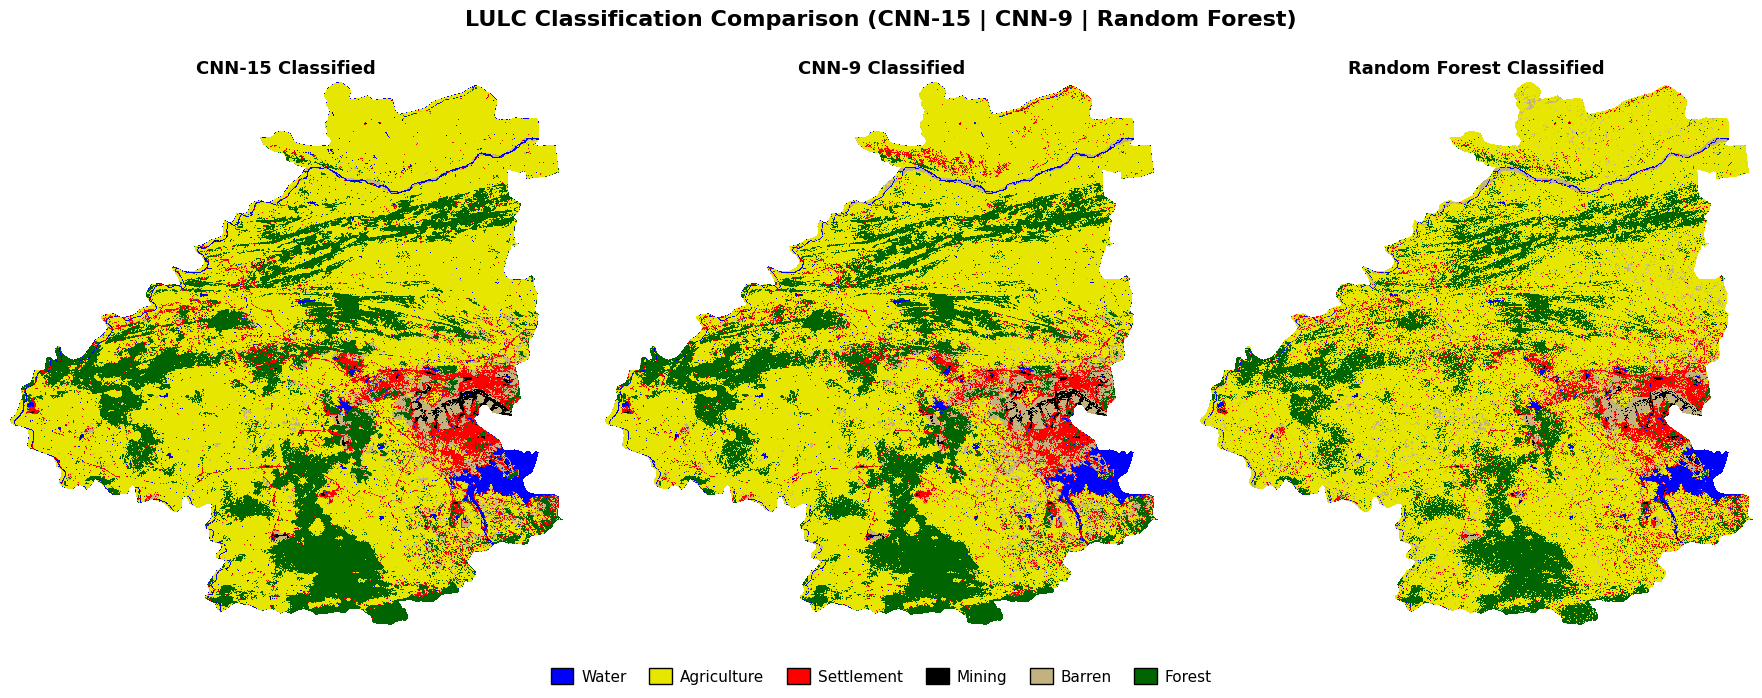


Visualization completed.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rasterio.enums import Resampling
from matplotlib.colors import ListedColormap, BoundaryNorm

print("Displaying CNN-15, CNN-9 and Random Forest LULC maps...")

lulc_palette = [
    '#0000FF',  # 1: Water
    '#E6E600',  # 2: Agriculture
    '#FF0000',  # 3: Settlement
    '#000000',  # 4: Mining
    '#C2B280',  # 5: Barren
    '#006400'   # 6: Forest
]

lulc_cmap = ListedColormap(lulc_palette)
lulc_cmap.set_bad(color='white', alpha=0)
boundaries = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]
lulc_norm = BoundaryNorm(boundaries, lulc_cmap.N)

SCALE = 6


def read_classified_downsampled(src, scale=6):
    h = max(1, src.height // scale)
    w = max(1, src.width // scale)
    img = src.read(
        1,
        out_shape=(h, w),
        resampling=Resampling.nearest
    ).astype(np.float32)
    return img


def remap_cnn_image_to_standard(img):
    """Remap entire CNN image from 0-5 to 1-6 standard format"""
    result = np.full_like(img, np.nan, dtype=np.float32)
    result[img == 0] = 6  # Forest
    result[img == 1] = 1  # Water
    result[img == 2] = 2  # Agriculture
    result[img == 3] = 3  # Settlement
    result[img == 4] = 4  # Mining
    result[img == 5] = 5  # Barren
    return result


def process_rf_image(img):
    result = img.astype(np.float32).copy()
    result[(result < 1) | (result > 6)] = np.nan
    return result


# Create AOI mask from RF image
with rasterio.open(RF_IMG_PATH) as rf_src:
    rf_raw = read_classified_downsampled(rf_src, scale=SCALE)
    rf_processed = process_rf_image(rf_raw)
    aoi_mask = (rf_raw >= 1) & (rf_raw <= 6)

print(f"AOI mask created from RF image: {np.sum(aoi_mask)} valid pixels")

images_to_view = [
    ("CNN-15 Classified", CNN15_IMG_PATH, True),
    ("CNN-9 Classified", CNN9_IMG_PATH, True),
    ("Random Forest Classified", RF_IMG_PATH, False),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor='white')

for ax, (title, path, is_cnn) in zip(axes, images_to_view):
    with rasterio.open(path) as src:
        img = read_classified_downsampled(src, scale=SCALE)

        print(f"\n{title}:")
        print(f"  Shape: {img.shape}")
        print(f"  Unique values (raw): {np.unique(img)[:10]}")

        if is_cnn:
            processed = remap_cnn_image_to_standard(img)
            processed[~aoi_mask] = np.nan
        else:
            processed = rf_processed

        valid_processed = processed[~np.isnan(processed)]
        if len(valid_processed) > 0:
            print(f"  Unique values (after processing): {np.unique(valid_processed)}")
            for cls in range(1, 7):
                count = np.sum(valid_processed == cls)
                pct = 100 * count / len(valid_processed)
                print(f"    Class {cls} ({STANDARD_CLASS_LABELS[cls]}): {pct:.1f}%")

        masked_img = np.ma.masked_invalid(processed)

        im = ax.imshow(
            masked_img,
            cmap=lulc_cmap,
            norm=lulc_norm,
            interpolation='nearest'
        )
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis("off")
        ax.set_facecolor('white')

legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor='black', linewidth=1, label=label)
    for label, color in zip(STANDARD_CLASS_LABELS.values(), lulc_palette)
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=11,
    frameon=False,
    handlelength=1.5,
    handleheight=1.2,
    handletextpad=0.5,
    columnspacing=1.5
)

plt.suptitle("LULC Classification Comparison (CNN-15 | CNN-9 | Random Forest)",
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig('lulc_comparison_fixed.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\nVisualization completed.")

In [5]:
try:
    print("\n" + "="*60)
    print("SAMPLING CONFIGURATION")
    print("="*60)

    # Choose source image for sampling
    print("\nWhich classified image should be used as the basis for sampling?")
    print("  1. CNN-9  (recommended - uses classes 0-5)")
    print("  2. CNN-15 (uses classes 0-5)")
    print("  3. Random Forest (uses classes 1-6)")

    source_choice = ""
    while source_choice not in ["1", "2", "3"]:
        source_choice = input("Enter choice (1/2/3): ").strip()

    if source_choice == "1":
        SAMPLING_IMAGE_PATH = CNN9_IMG_PATH
        IS_CNN_IMAGE = True
        source_name = "CNN-9"
    elif source_choice == "2":
        SAMPLING_IMAGE_PATH = CNN15_IMG_PATH
        IS_CNN_IMAGE = True
        source_name = "CNN-15"
    else:
        SAMPLING_IMAGE_PATH = RF_IMG_PATH
        IS_CNN_IMAGE = False
        source_name = "Random Forest"

    print(f"\n✓ Using {source_name} image for sampling")

    # Choose sampling method
    method = ""
    while method not in ["random", "stratified"]:
        method = input("\nSelect sampling method (random / stratified): ").strip().lower()

    if method == "stratified":
        while True:
            try:
                points_per_class = int(input("How many reference points PER CLASS? "))
                if points_per_class <= 0:
                    raise ValueError
                break
            except ValueError:
                print("Please enter a valid positive integer.")

        sampling_plan = create_stratified_sampling_plan(
            SAMPLING_IMAGE_PATH,
            IS_CNN_IMAGE,
            points_per_class
        )

    elif method == "random":
        while True:
            try:
                total_points = int(input("How many TOTAL random reference points? "))
                if total_points <= 0:
                    raise ValueError
                break
            except ValueError:
                print("Please enter a valid positive integer.")

        sampling_plan = create_random_sampling_plan(
            SAMPLING_IMAGE_PATH,
            IS_CNN_IMAGE,
            total_points
        )

    num_points_total = len(sampling_plan)

    if num_points_total == 0:
        print("\n⚠️ Warning: No sampling points were generated.")
        print("Check that your class labels match the values in the image.")
        base_dataset.close()
        cnn15_dataset.close()
        cnn9_dataset.close()
        rf_dataset.close()
    else:
        random.shuffle(sampling_plan)
        print(f"\n✅ Starting data collection for {num_points_total} points...")
        print("="*60 + "\n")
        display(progress_label, output_container)
        next_point()

except Exception as e:
    print(f"\n❌ An error occurred: {e}")
    import traceback
    traceback.print_exc()
    try:
        base_dataset.close()
        cnn15_dataset.close()
        cnn9_dataset.close()
        rf_dataset.close()
    except:
        pass


SAMPLING CONFIGURATION

Which classified image should be used as the basis for sampling?
  1. CNN-9  (recommended - uses classes 0-5)
  2. CNN-15 (uses classes 0-5)
  3. Random Forest (uses classes 1-6)
Enter choice (1/2/3): 3

✓ Using Random Forest image for sampling

Select sampling method (random / stratified): stratified
How many reference points PER CLASS? 20
Creating stratified sampling plan from: /content/drive/My Drive/Internship_project/Singrauli_LULC_RF_2024.tif
  Image type: RF (1-6)
  - Finding pixels for class 1: Water
  - Finding pixels for class 2: Agriculture
  - Finding pixels for class 3: Settlement
  - Finding pixels for class 4: Mining
  - Finding pixels for class 5: Barren
  - Finding pixels for class 6: Forest
Sampling plan created: 120 total points

✅ Starting data collection for 120 points...



Label(value='')

Output()